In [2]:
import numpy as np
import scprep
import phate
import sys
sys.path.append('..')
from run.run_gspa import calculate_wavelet_dictionary
from run.run_ae_default_config import run_ae
from utils import *
from sklearn import cluster
import scanpy
import matplotlib.pyplot as plt
import leidenalg

2023-11-02 21:03:55.185052: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-11-02 21:03:55.233694: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-11-02 21:03:55.234669: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-02 21:03:56.133804: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Get single-cell data (cell x gene)

In this example, we have 2000 simulated cells and 8823 genes. The dataset is a noisy branching dataset with 3 branches.

In [6]:
data = np.load('data/example.npz')

In [7]:
for k in data:
    print (k)

counts
pseudotime


In [ ]:
phate_op = phate.PHATE(random_state=42, use_pygsp=True, verbose=False)
data_phate = phate_op.fit_transform(data['counts'])
G = phate_op.graph

In [ ]:
scprep.plot.scatter2d(data_phate, c=data['pseudotime'], cmap='inferno', figsize=(6,5), dpi=200, title='Pseudotime')

## Get gene embeddings

In [6]:
data_hvg = scprep.select.highly_variable_genes(data['counts'])
data_hvg = data_hvg / np.linalg.norm(data_hvg, axis=0)

In [7]:
uniform_signal = np.ones((1, G.N))
uniform_signal = uniform_signal / np.linalg.norm(uniform_signal, axis=1).reshape(-1,1)

In [8]:
cell_dictionary, wavelet_sizes = calculate_wavelet_dictionary(G, use_reduced=True)

Maximum scale: 7


100%|██████████| 5/5 [00:05<00:00,  1.01s/it]


In [9]:
results = {}

signals_projected = project(data_hvg.T, cell_dictionary)
uniform_projected = project(uniform_signal, cell_dictionary)
signals_reduced = svd(signals_projected)
results['signal_embedding'] = run_ae(signals_reduced)
results['localization_score'] = calculate_localization(uniform_projected, signals_projected)

np.savez('./results/example_signal_embeddings.npz', signal_embedding=results['signal_embedding'],
         localization_score=results['localization_score'])

Epoch 1/100


2023-11-02 20:58:24.453315: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


53/53 [==============================] - 1s 9ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 2/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 3/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 4/100
53/53 [==============================] - 0s 6ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 5/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 6/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 7/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 8/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 9/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 10/100
53/53 [==============================] - 0s 5ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 11/100
53/53 [=

## Analyze gene embeddings

In [10]:
adata = scanpy.AnnData(data_hvg)

In [11]:
gene_embeddings = np.load('./results/example_signal_embeddings.npz')

In [12]:
gene_phate_op = phate.PHATE(random_state=42, verbose=False)
gene_phate = gene_phate_op.fit_transform(gene_embeddings['signal_embedding'])

In [13]:
adata.var['gene_clusters'] = cluster.KMeans(n_clusters=9, random_state=42).fit_predict(gene_embeddings['signal_embedding'])
conv = {0:0, 3:1, 2:2, 4:3, 1:4, 7:5, 8:6, 6:7, 5:8} # reorder clusters to match order in plot
adata.var['gene_clusters'] = [conv[x] for x in adata.var['gene_clusters']]

<Axes: xlabel='Gene PHATE1', ylabel='Gene PHATE2'>

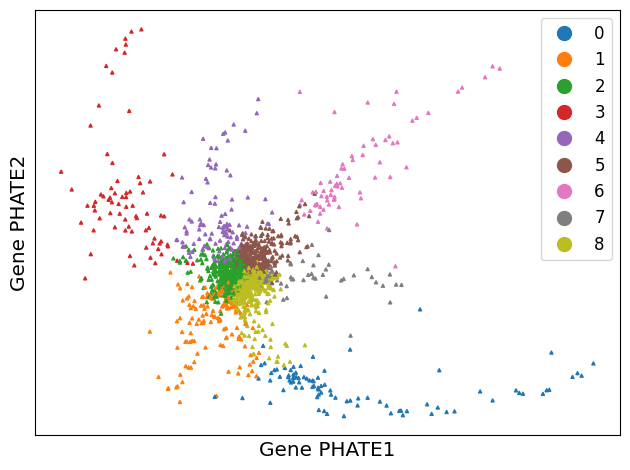

In [14]:
scprep.plot.scatter2d(gene_phate, c=adata.var['gene_clusters'], ticks=None, marker='^', label_prefix='Gene PHATE')

In [15]:
for c in np.unique(adata.var['gene_clusters']):
    scanpy.tl.score_genes(adata, gene_list=adata.var_names[adata.var['gene_clusters'] == c],
                          random_state=0, score_name=f'GM_{c}_score',
                          n_bins=int(adata.n_vars * 0.25))

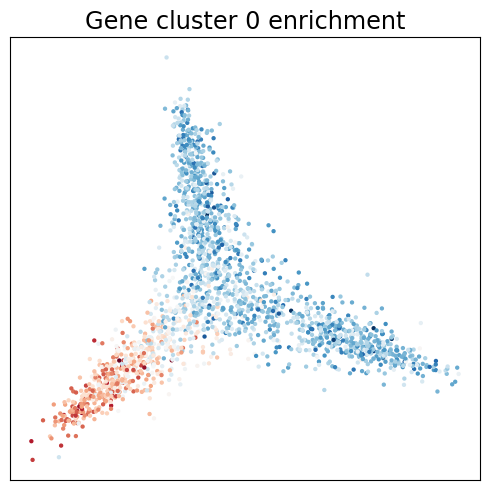

<Figure size 640x480 with 0 Axes>

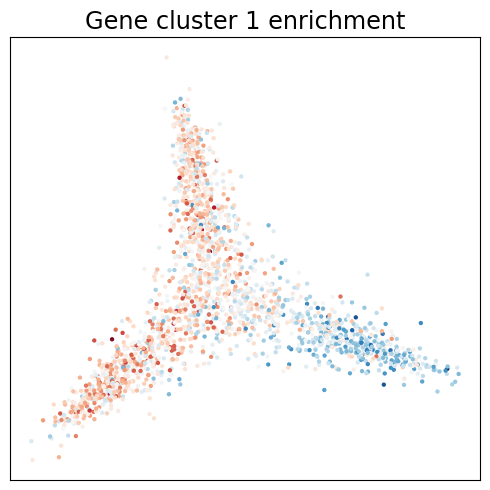

<Figure size 640x480 with 0 Axes>

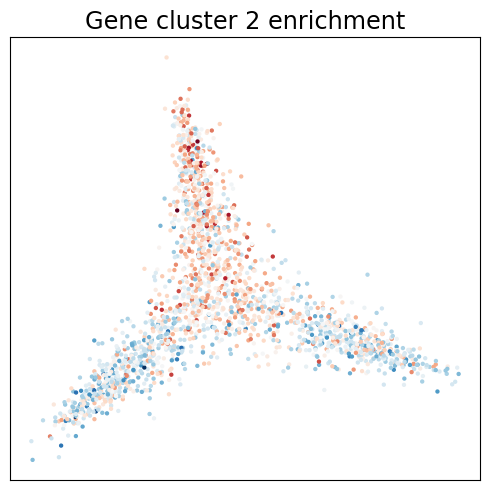

<Figure size 640x480 with 0 Axes>

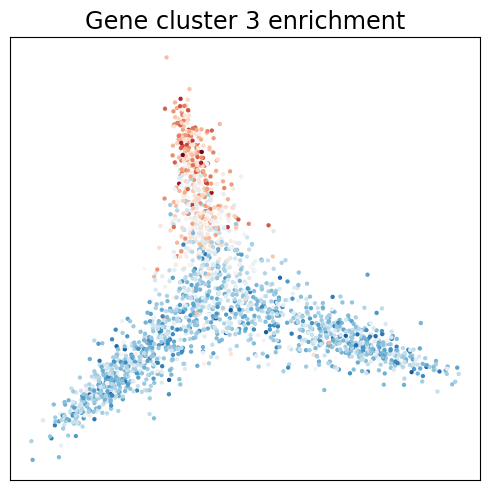

<Figure size 640x480 with 0 Axes>

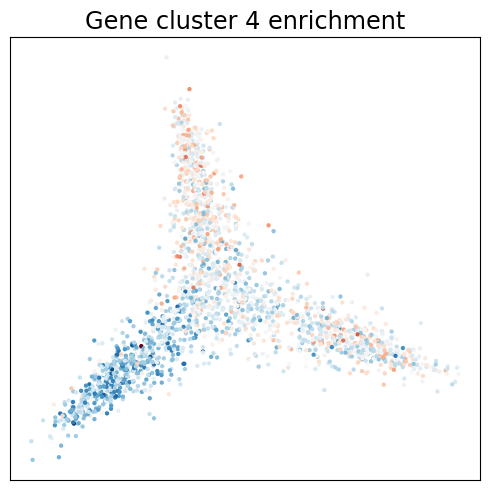

<Figure size 640x480 with 0 Axes>

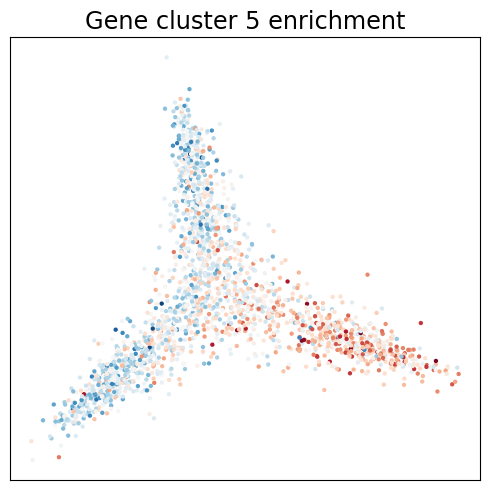

<Figure size 640x480 with 0 Axes>

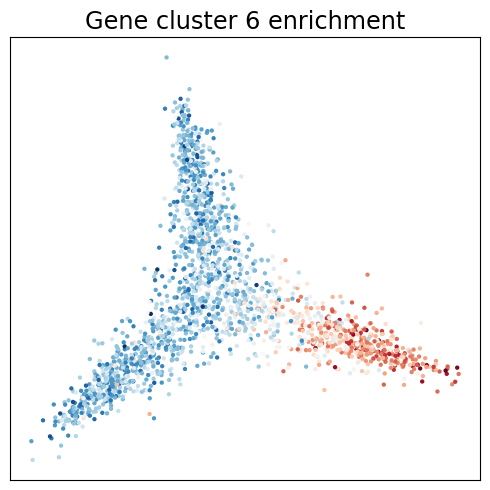

<Figure size 640x480 with 0 Axes>

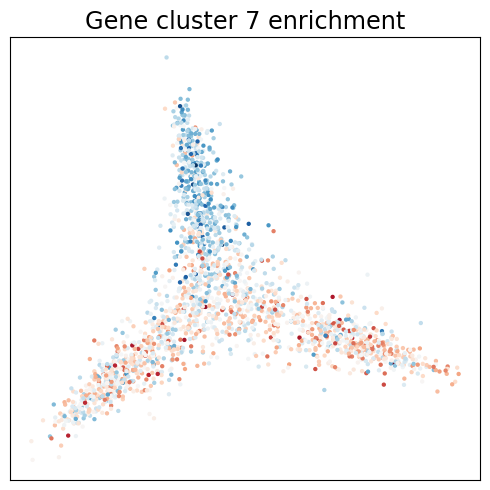

<Figure size 640x480 with 0 Axes>

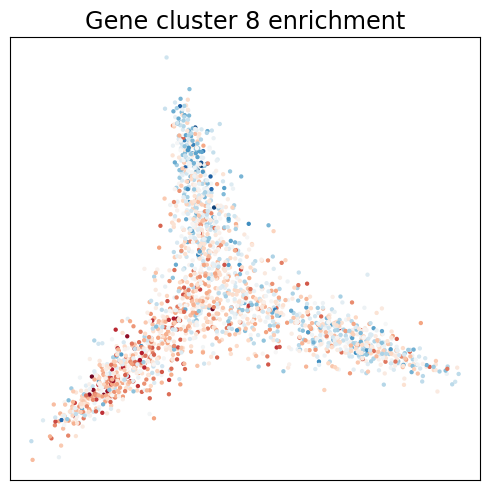

<Figure size 640x480 with 0 Axes>

In [16]:
for c in np.unique(adata.var['gene_clusters']):
    scprep.plot.scatter2d(data_phate,
                      c=adata.obs[f'GM_{c}_score'], colorbar=False, ticks=None, figsize=(5,5),
                      title=f'Gene cluster {c} enrichment', dpi=200, cmap='RdBu_r')
    
    plt.show(); plt.clf()

## Analyze localization

<Axes: xlabel='Gene PHATE1', ylabel='Gene PHATE2'>

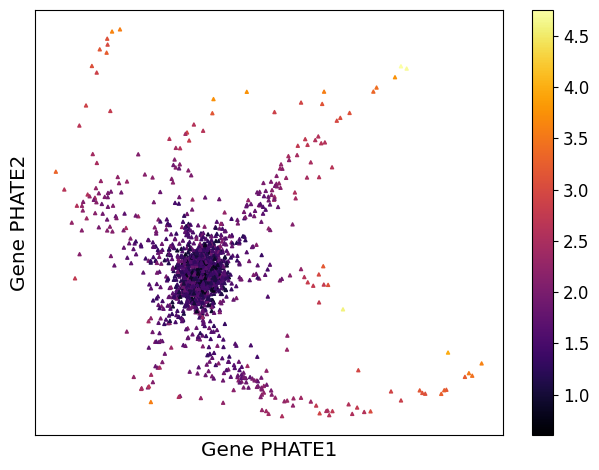

In [17]:
scprep.plot.scatter2d(gene_phate, c=gene_embeddings['localization_score'], ticks=None, marker='^', label_prefix='Gene PHATE')